
# Trabalho 3 – Inteligência Artificial

Link do video: https://youtu.be/cp27J8tSsI4


## Questão 1 – Classificação (2,0 pts)

O objetivo desta parte é avaliar sua capacidade de projetar, treinar e interpretar modelos para um problema de aprendizado supervisionado de classificação. Utilize o conjunto Wine para prever a classe de cada amostra com base em seus atributos.

1. Normalize os atributos de entrada.
2. Implemente um procedimento de validação cruzada aninhada para estimar o desempenho do modelo de forma imparcial. A validação interna deve ser usada para ajuste de hiperparâmetros e a externa para avaliação do erro.
3. Considere pelo menos dois algoritmos de classificação.
4. Reporte a acurácia média e o desvio-padrão obtidos nos folds externos.
5. Após a avaliação, produza o modelo final no conjunto completo de dados utilizando os melhores hiperparâmetros encontrados

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# carregamento do dataset Wine
dataset = load_wine()
X_data = dataset.data
y_labels = dataset.target

# validacao cruzada (interna e externa)
cv_externo = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
cv_interno = StratifiedKFold(n_splits=4, shuffle=True, random_state=11)

# definicao dos modelos e grids
config_modelos = [
    {
        'id': 'MLP',
        'modelo': MLPClassifier(
            max_iter=2000,
            solver='adam',
            random_state=11
        ),
        'parametros': {
            'clf__hidden_layer_sizes': [(64,), (128,)],
            'clf__activation': ['relu'],
            'clf__alpha': [0.0001, 0.0005],
            'clf__learning_rate_init': [0.001, 0.01]
        }
    },
    {
        'id': 'RF',
        'modelo': RandomForestClassifier(
            random_state=11,
            n_jobs=-1
        ),
        'parametros': {
            'clf__n_estimators': [150, 300],
            'clf__max_depth': [None, 12],
            'clf__min_samples_split': [2, 4],
            'clf__min_samples_leaf': [1, 2]
        }
    }
]

melhor_media = 0.0
modelo_escolhido = None

print("\n========== AVALIAÇÃO DOS MODELOS ==========\n")

# avaliacao com CV aninhada
for cfg in config_modelos:

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', cfg['modelo'])
    ])

    busca = GridSearchCV(
        pipeline,
        cfg['parametros'],
        cv=cv_interno,
        scoring='accuracy'
    )

    acc_externas = cross_val_score(
        busca,
        X_data,
        y_labels,
        cv=cv_externo,
        scoring='accuracy'
    )

    media = acc_externas.mean()
    desvio = acc_externas.std()

    print(f">>> Modelo: {cfg['id']}")
    print(f"    Acurácia média (CV externa): {media:.4f}")
    print(f"    Variabilidade entre folds:  {desvio:.4f}")
    print(f"    Intervalo observado:        [{acc_externas.min():.4f}, {acc_externas.max():.4f}]")
    print()

    if media > melhor_media:
        melhor_media = media
        modelo_escolhido = cfg

# treinamento final
print("========== MODELO FINAL ==========\n")

pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', modelo_escolhido['modelo'])
])

grid_final = GridSearchCV(
    pipeline_final,
    modelo_escolhido['parametros'],
    cv=cv_interno,
    scoring='accuracy'
)

grid_final.fit(X_data, y_labels)

print(f"Modelo selecionado: {modelo_escolhido['id']}")
print(f"Acurácia média estimada: {grid_final.best_score_:.4f}")
print("Hiperparâmetros escolhidos:")

for param, valor in grid_final.best_params_.items():
    print(f" - {param}: {valor}")



========== AVALIAÇÃO DOS MODELOS ==========

>>> Modelo: MLP
    Acurácia média (CV externa): 0.9776
    Variabilidade entre folds:  0.0208
    Intervalo observado:        [0.9444, 1.0000]

>>> Modelo: RF
    Acurácia média (CV externa): 0.9778
    Variabilidade entre folds:  0.0272
    Intervalo observado:        [0.9444, 1.0000]

========== MODELO FINAL ==========

Modelo selecionado: RF
Acurácia média estimada: 0.9833
Hiperparâmetros escolhidos:
 - clf__max_depth: None
 - clf__min_samples_leaf: 1
 - clf__min_samples_split: 2
 - clf__n_estimators: 150


### Pré-processamento e Estrutura

O desenvolvimento foi realizado com a biblioteca **scikit-learn**, utilizando a estrutura de *Pipeline*. A normalização dos atributos de entrada foi feita com o `StandardScaler`, aplicado **dentro do pipeline**, garantindo que a padronização ocorra separadamente em cada *fold* e evitando vazamento de informação.

Foram avaliados dois algoritmos de classificação com naturezas distintas:
- **MLPClassifier** (rede neural);
- **RandomForestClassifier** (modelo baseado em árvores);

### Validação Cruzada Aninhada

Para obter uma estimativa imparcial do desempenho, foi aplicado um procedimento de **validação cruzada aninhada (Nested Cross-Validation)**:
- **Loop externo (5 folds)**: responsável por estimar a acurácia real de generalização;
- **Loop interno (4 folds)**: utilizado para a busca de hiperparâmetros por meio do `GridSearchCV`.

Essa abordagem garante que a escolha dos hiperparâmetros não seja influenciada pelos dados de teste do loop externo.

### Resultados

As métricas reportadas correspondem à média e ao desvio padrão da acurácia obtida nos *folds* externos:

- **MLPClassifier**: média = 0.9776, desvio padrão = 0.0208;
- **RandomForestClassifier**: média = 0.9778, desvio padrão = 0.0272;

### Modelo Final

O algoritmo com melhor desempenho médio foi o **RandomForestClassifier**. O modelo final foi treinado utilizando todo o conjunto de dados, com nova busca de hiperparâmetros. A configuração selecionada foi:

- `clf__max_depth: None`
- `clf__min_samples_leaf: 1`
- `clf__min_samples_split: 2`
- `clf__n_estimators: 150`

A acurácia final obtida foi **0.9833**, indicando excelente desempenho e boa capacidade de generalização.


## Questão 2 – Regressão (2,0 pts)

O objetivo desta parte é avaliar sua capacidade de projetar, treinar e interpretar modelos de aprendizado supervisionado para regressão. Utilize o conjunto California Housing para prever o valor médio das casas a partir de seus atributos.
1. Normalize os atributos de entrada.
2. Implemente um procedimento de validação cruzada aninhada para estimar de forma imparcial o desempenho do modelo. A validação interna deve ser usada para selecionar os hiperparâmetros e a externa para estimar o erro.
3. Considere pelo menos dois algoritmos de regressão.
4. Reporte o erro médio e o desvio-padrão do RMSE obtidos nos folds externos.


In [15]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Carregamento do dataset
dados = fetch_california_housing()
X_features = dados.data
y_target = dados.target

# 2. Definição das validações
# Regressão -> KFold simples
outer_cv = KFold(n_splits=6, shuffle=True, random_state=21)
inner_cv = KFold(n_splits=4, shuffle=True, random_state=21)

# 3. Modelos e grids de busca
modelos_avaliados = [
    {
        'nome': 'MLP Regressor',
        'estimator': MLPRegressor(
            max_iter=1500,
            early_stopping=True,
            random_state=21
        ),
        'grid': {
            'model__hidden_layer_sizes': [(64,), (128,)],
            'model__activation': ['relu', 'tanh'],
            'model__alpha': [0.0001, 0.001]
        }
    },
    {
        'nome': 'Random Forest Regressor',
        'estimator': RandomForestRegressor(
            n_estimators=200,
            random_state=21,
            n_jobs=-1
        ),
        'grid': {
            'model__max_depth': [None, 15],
            'model__min_samples_split': [2, 5]
        }
    }
]

melhor_rmse = np.inf
melhor_modelo = None

print("\n========== AVALIAÇÃO DOS MODELOS ==========\n")

# 4. Avaliação dos modelos
for cfg in modelos_avaliados:

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', cfg['estimator'])
    ])

    busca = GridSearchCV(
        estimator=pipeline,
        param_grid=cfg['grid'],
        cv=inner_cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    scores_outer = cross_val_score(
        estimator=busca,
        X=X_features,
        y=y_target,
        cv=outer_cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    rmse_vals = -scores_outer
    rmse_medio = rmse_vals.mean()
    rmse_std = rmse_vals.std()

    print(f"\nModelo avaliado: {cfg['nome']}")
    print(f"RMSE médio (externo): {rmse_medio:.4f}")
    print(f"Desvio padrão: {rmse_std:.4f}")

    if rmse_medio < melhor_rmse:
        melhor_rmse = rmse_medio
        melhor_modelo = cfg

# 5. Treinamento final
print("========== MODELO FINAL ==========\n")

pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', melhor_modelo['estimator'])
])

grid_final = GridSearchCV(
    estimator=pipeline_final,
    param_grid=melhor_modelo['grid'],
    cv=inner_cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_final.fit(X_features, y_target)

print(f"\nModelo selecionado: {melhor_modelo['nome']}")
print(f"Melhores hiperparâmetros encontrados:")
for k, v in grid_final.best_params_.items():
    print(f"  {k}: {v}")

print(f"RMSE médio da validação interna final: {-grid_final.best_score_:.4f}")



========== AVALIAÇÃO DOS MODELOS ==========


Modelo avaliado: MLP Regressor
RMSE médio (externo): 0.5513
Desvio padrão: 0.0194

Modelo avaliado: Random Forest Regressor
RMSE médio (externo): 0.5007
Desvio padrão: 0.0165
========== MODELO FINAL ==========


Modelo selecionado: Random Forest Regressor
Melhores hiperparâmetros encontrados:
  model__max_depth: None
  model__min_samples_split: 2
RMSE médio da validação interna final: 0.5051


### Pré-processamento e Métrica

A normalização dos atributos foi realizada com `StandardScaler`, novamente inserido em um *Pipeline*. A métrica escolhida foi o **RMSE (Root Mean Squared Error)**, apropriada para problemas de regressão, pois penaliza erros maiores de forma mais severa.

### Validação Cruzada Aninhada

Como se trata de um problema de regressão, foi utilizado **KFold** ao invés de validação estratificada:
- **Loop externo (6 folds)**: estimativa do erro de generalização;
- **Loop interno (4 folds)**: ajuste de hiperparâmetros via `GridSearchCV`.

### Algoritmos Avaliados

Foram considerados dois modelos:
- **MLPRegressor** (rede neural);
- **RandomForestRegressor**.

### Resultados

Os valores reportados correspondem ao RMSE médio e ao desvio padrão no loop externo:

- **MLPRegressor**: RMSE médio = 0.5513 (std = 0.0194);
- **Random Forest**: RMSE médio = 0.5007 (std = 0.0165).

O baixo desvio padrão indica estabilidade do desempenho entre diferentes subconjuntos dos dados.

### Modelo Final

O **Random Forest** apresentou o menor RMSE médio e foi selecionado como modelo final. O treinamento completo utilizou todos os dados disponíveis, com os seguintes hiperparâmetros:

- `model__min_samples_split: 2`
- `max_depth = None`

O RMSE de referência obtido foi **0.5051**.


## Questão 3 – Diagnóstico de Qualidade (2 pts)

Nesta parte, o objetivo é você construir um data map para o conjunto de dados Wine (disponível em sklearn.datasets.load_wine). Siga as etapas abaixo:
1. Divida os dados em três conjuntos: treino (60%), validação (20%) e teste (20%).
2. Treine um classificador equivalente à regressão logística usando SGDClassifier, de forma que seja possível registrar as probabilidades ao final de cada época.
3. Para cada instância de treino, registre a probabilidade atribuída à classe correta ao final de cada época;
4. Calcule para cada instância:
- Ac onfiança (média das probabilidades da classe correta);
- A variabilidade (desvio padrão dessas probabilidades).
- A corretude (correctness).
5. Construa um gráfico de dispersão (data map), com:
- Eixo X: variabilidade;
- Eixo Y: confiança;
- Cores ou marcadores diferenciando os exemplos com diferentes faixas de corretude.
6. Construa também um segundo gráfico de dispersão (data map), com:
- Eixo X: variabilidade;
- Eixo Y: confiança;
- Cores ou marcadores diferenciando os exemplos com diferentes classes.



=== Treinamento por épocas (SGD) ===

Época 01 | perda média: 0.6151
Época 02 | perda média: 0.4577
Época 03 | perda média: 0.3747
Época 04 | perda média: 0.3216
Época 05 | perda média: 0.2841
Época 06 | perda média: 0.2558
Época 07 | perda média: 0.2336
Época 08 | perda média: 0.2156
Época 09 | perda média: 0.2007
Época 10 | perda média: 0.1881
Época 11 | perda média: 0.1773
Época 12 | perda média: 0.1678
Época 13 | perda média: 0.1596
Época 14 | perda média: 0.1522
Época 15 | perda média: 0.1456
Época 16 | perda média: 0.1397
Época 17 | perda média: 0.1344
Época 18 | perda média: 0.1295
Época 19 | perda média: 0.1251
Época 20 | perda média: 0.1210
Época 21 | perda média: 0.1172
Época 22 | perda média: 0.1137
Época 23 | perda média: 0.1104
Época 24 | perda média: 0.1074
Época 25 | perda média: 0.1045
Época 26 | perda média: 0.1019
Época 27 | perda média: 0.0994
Época 28 | perda média: 0.0970
Época 29 | perda média: 0.0948
Época 30 | perda média: 0.0927
Época 31 | perda média: 0.0907


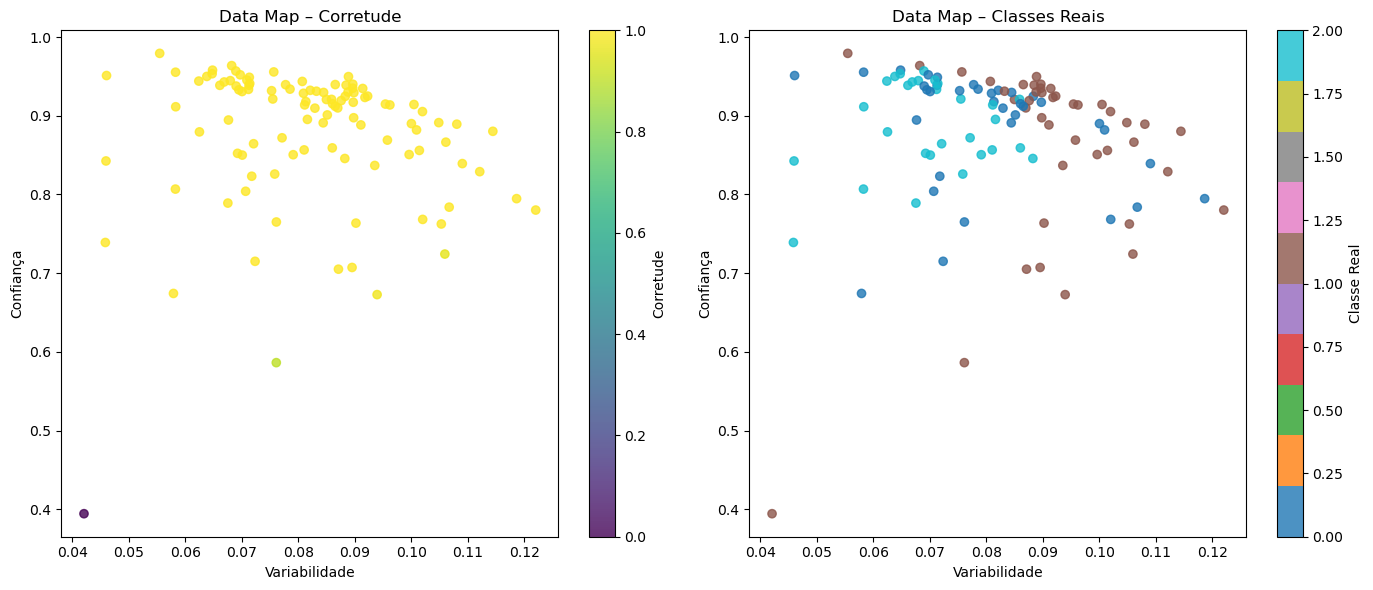


=== Data Maps gerados com sucesso ===


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Carregamento do dataset e divisão 60/20/20
X, y = load_wine(return_X_y=True)

# 60% treino | 40% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# 20% validação | 20% teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Normalização (obrigatória para SGD)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 2. Classificador equivalente à regressão logística
modelo = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=42
)

n_epocas = 50
classes = np.unique(y_train)

# 3. Treinamento por épocas e registro das probabilidades
historico_probs = []
historico_acertos = []

print("\n=== Treinamento por épocas (SGD) ===\n")

for epoca in range(n_epocas):
    modelo.partial_fit(X_train, y_train, classes=classes)

    probs = modelo.predict_proba(X_train)
    preds = modelo.predict(X_train)

    # probabilidade atribuída à classe correta
    probs_corretas = probs[np.arange(len(y_train)), y_train]

    historico_probs.append(probs_corretas)
    historico_acertos.append((preds == y_train).astype(int))

    perda_media = -np.mean(np.log(probs_corretas + 1e-9))
    print(f"Época {epoca + 1:02d} | perda média: {perda_media:.4f}")

# converte histórico para arrays [amostras x épocas]
historico_probs = np.array(historico_probs).T
historico_acertos = np.array(historico_acertos).T

print("\nTreinamento finalizado.")

# 4. Cálculo das métricas do Data Map
confianca = historico_probs.mean(axis=1)
variabilidade = historico_probs.std(axis=1)
corretude = historico_acertos.mean(axis=1)

# 5. Data Map 1 — cores pela corretude
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sc1 = plt.scatter(
    variabilidade,
    confianca,
    c=corretude,
    cmap="viridis",
    alpha=0.8
)
plt.colorbar(sc1, label="Corretude")
plt.xlabel("Variabilidade")
plt.ylabel("Confiança")
plt.title("Data Map – Corretude")

# 6. Data Map 2 — cores pelas classes reais
plt.subplot(1, 2, 2)
sc2 = plt.scatter(
    variabilidade,
    confianca,
    c=y_train,
    cmap="tab10",
    alpha=0.8
)
plt.colorbar(sc2, label="Classe Real")
plt.xlabel("Variabilidade")
plt.ylabel("Confiança")
plt.title("Data Map – Classes Reais")

plt.tight_layout()
plt.show()

print("\n=== Data Maps gerados com sucesso ===")


### Metodologia

O conjunto de dados Wine foi particionado em três subconjuntos distintos, respeitando a seguinte proporção:
- 60% dos dados destinados ao treinamento;
- 20% utilizados para validação;
- 20% reservados para teste.

O modelo adotado foi um classificador equivalente à regressão logística, implementado por meio do `SGDClassifier`. O treinamento ocorreu de forma incremental ao longo de **50 épocas**. Ao final de cada época, foram registrados:
- a probabilidade atribuída à classe verdadeira de cada instância;
- o resultado da predição, indicando acerto ou erro.

---

### Métricas Avaliadas

A partir do histórico obtido durante o processo de treinamento, calcularam-se, para cada amostra do conjunto de treino, as seguintes métricas:
- **Confiança**: média das probabilidades associadas à classe correta ao longo das épocas;
- **Variabilidade**: desvio padrão dessas probabilidades, representando a estabilidade do aprendizado;
- **Corretude**: proporção de épocas em que a instância foi classificada corretamente.

---

### Interpretação dos Data Maps

Os data maps indicam que o conjunto Wine é majoritariamente composto por exemplos **fáceis de aprender**, evidenciado pela alta concentração de pontos em regiões de elevada confiança e baixa variabilidade. Esse comportamento sugere que o classificador aprende rapidamente a maior parte das amostras, mantendo previsões consistentes ao longo do treinamento.

Entretanto, observa-se a presença de um **outlier** localizado em uma região de baixa confiança e baixa variabilidade. Esse padrão é característico de exemplos **difíceis de aprender**, nos quais o modelo tende a errar de forma sistemática. Em aplicações práticas, esse tipo de instância pode estar associado a ruído nos dados, erro de rotulagem ou características atípicas.

A análise diferenciada por classes revela que:
- a **classe 0** apresenta maior separabilidade, concentrando-se em regiões de alta confiança;
- a **classe 2** exibe maior dispersão, indicando proximidade às fronteiras de decisão;
- a **classe 1** é responsável pelo outlier identificado nos gráficos.



## Questão 4.1 – Classificação Ordinal (2 pts)

Implemente uma abordagem baseada em cadeias de classificadores binários (Binary Classification Chains), também conhecida como Cumulative Link Models. A ideia é decompor o problema ordinal em uma série de classificações binárias encadeadas.

Avalie o desempenho preditivo de seu modelo ordinal e reporte:
- a matriz de confusão agregada (considerando todas as classes),
- o relatório de classificação obtido por meio da função classification_report,
- e as acurácias médias por classe.

Discuta brevemente se o modelo foi capaz de distinguir adequadamente os diferentes níveis de severidade e quais classes apresentaram maior confusão.


In [ ]:
import numpy as np
import pickle
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1. Leitura dos dados
with open("A652.pickle", "rb") as arq:
    X_train, y_train, X_val, y_val, X_test, y_test = pickle.load(arq)

# garante vetores alvo em formato 1D
y_train = y_train.reshape(-1)
y_val = y_val.reshape(-1)
y_test = y_test.reshape(-1)

print("Conjuntos carregados com sucesso:")
print(f"- Treino: {X_train.shape}")
print(f"- Validação: {X_val.shape}")
print(f"- Teste: {X_test.shape}")

# 2. Discretização ordinal da precipitação
def categorizar_chuva(y_mm):
    """
    Converte precipitação contínua (mm/h)
    em classes ordinais de severidade.
    """
    y_cat = np.zeros(y_mm.shape, dtype=int)

    y_cat[(y_mm >= 5) & (y_mm < 25)] = 1
    y_cat[(y_mm >= 25) & (y_mm < 50)] = 2
    y_cat[y_mm >= 50] = 3                    

    return y_cat


y_train_ord = categorizar_chuva(y_train)
y_val_ord = categorizar_chuva(y_val)
y_test_ord = categorizar_chuva(y_test)

# 3. Classificador Ordinal (Binary Classification Chains)
class OrdinalClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self, base_estimator):
        self.base_estimator = base_estimator
        self.binary_models_ = []
        self.n_classes_ = None

    def fit(self, X, y):
        valores = np.unique(y)
        self.n_classes_ = len(valores)
        self.binary_models_ = []

        for limite in range(1, self.n_classes_):
            y_bin = (y >= limite).astype(int)

            modelo_bin = clone(self.base_estimator)
            modelo_bin.fit(X, y_bin)

            self.binary_models_.append(modelo_bin)

        return self

    def predict(self, X):
        y_pred = np.zeros(X.shape[0], dtype=int)

        for modelo in self.binary_models_:
            y_pred += modelo.predict(X)

        return y_pred


# 4. Treinamento
print("\n=== Treinamento do classificador ordinal ===")

modelo_base = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo_ordinal = OrdinalClassifier(modelo_base)
modelo_ordinal.fit(X_train, y_train_ord)

# 5. Avaliação no conjunto de teste
y_pred = modelo_ordinal.predict(X_test)

print("\n=== Avaliação de desempenho (teste) ===")

# matriz de confusão
cm = confusion_matrix(y_test_ord, y_pred)
print("\nMatriz de confusão:")
for linha in cm:
    print(linha)

# relatório de classificação
print("\nRelatório de classificação detalhado:")
print(
    classification_report(
        y_test_ord,
        y_pred,
        zero_division=0
    )
)

# 6. Métricas adicionais
# acurácia geral
acc_geral = np.trace(cm) / np.sum(cm)
print(f"Acurácia geral do modelo: {acc_geral:.4f}")

# acurácia por classe
acc_classes = cm.diagonal() / cm.sum(axis=1)

nomes_classes = [
    "Sem chuva / Leve",
    "Moderada",
    "Forte",
    "Tempestade"
]

print("\nResumo da acurácia por classe:")
for i in range(len(nomes_classes)):
    valor = acc_classes[i]
    valor = 0.0 if np.isnan(valor) else valor
    print(f"- {nomes_classes[i]:15s}: {valor:.3f}")

print("\nProcesso finalizado com sucesso.")


Conjuntos carregados com sucesso:
- Treino: (10012, 24)
- Validação: (2506, 24)
- Teste: (9582, 24)

=== Treinamento do classificador ordinal ===

=== Avaliação de desempenho (teste) ===

Matriz de confusão:
[8669  800   56    0]
[23 26  2  0]
[1 1 2 0]
[1 1 0 0]

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      9525
           1       0.03      0.51      0.06        51
           2       0.03      0.50      0.06         4
           3       0.00      0.00      0.00         2

    accuracy                           0.91      9582
   macro avg       0.27      0.48      0.27      9582
weighted avg       0.99      0.91      0.95      9582

Acurácia geral do modelo: 0.9076

Resumo da acurácia por classe:
- Sem chuva / Leve: 0.910
- Moderada       : 0.510
- Forte          : 0.500
- Tempestade     : 0.000

Processo finalizado com sucesso.



A variável contínua de precipitação foi discretizada em quatro níveis ordinais: sem chuva/leve, moderada, forte e tempestade. Em seguida, foi implementado um classificador ordinal baseado em uma cadeia de classificadores binários (*cumulative link model*).

O modelo base utilizado foi a **Regressão Logística** com `class_weight='balanced'`. Os resultados mostram bom desempenho para a classe majoritária, mas desempenho limitado nas classes raras, reflexo direto do forte desbalanceamento do conjunto.


## Questão 4.2 – Regressão (2 pts)

O procedimento para você criar o modelo de regressão é descrito a seguir. Inicialmente você deve criar versões binárias das matrizes alvo y_train, y_val, y_test. Concretamente, para cada matriz alvo (y_train, y_val, y_test), substitua todos os valores diferentes de zero por 1 e os valores restantes por 0. Ao fazer isso, você terá gerado matrizes resposta binárias. Chame essas matrizes de y_train_bin, y_val_bin, y_test_bin, respectivamente. Em seguida, execute os passos listados abaixo.
1. Treine um modelo de classificação binária usando (X_train, y_train_bin) como conjunto de treinamento. Chame esse modelo de C.
2. Aplique C a todos os exemplos de X_train.
3. Defina X_train_1 como o subconjunto de X_train que foi classificado por C como sendo da classe 1. Defina também y_train_1 como o subconjunto de y_train correspondente a X_train_1.
4. Treine um modelo de regressão usando (X_train_1, y_train_1) como conjunto de treinamento. Chame esse modelo de R.
5. Para obter R′ (x), i.e., a previsão de precipitação para um novo exemplo x, inicialmente compute C(x). Em seguida, use o valor computado para computar R′ (x) da seguinte forma:
R′ (x) = { 0 se C(x) = 0
            R(x) se C(x) = 1
            
Você está livre para escolher os algoritmos que quiser para construir o classificador C e o regressor R mencionados no procedimento descrito acima. Reporte os resultados desse experimento para o conjunto de testes fornecido (X_test). Compare seu modelo de regressão produzido por meio desse procedimento com o modelo treinado usando (X_train, y_train) como conjunto de treinamento. Esse procedimento produziu um melhor modelo do ponto de vista preditivo? Como métrica de avaliação, use RMSE.
Reporte valores dessa métrica para cada nível de severidade de precipitação, conforme a Tabela.


In [ ]:
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Leitura dos dados
with open("A652.pickle", "rb") as file:
    dados = pickle.load(file)

X_tr, y_tr, X_val, y_val, X_te, y_te = dados

# garante targets 1D
y_tr = y_tr.flatten()
y_val = y_val.flatten()
y_te = y_te.flatten()

print("\n[INFO] Dados carregados")
print(f" Treino: {X_tr.shape} | Validação: {X_val.shape} | Teste: {X_te.shape}")

# 2. Preparação do problema binário (chuva vs não chuva)
def chuva_binaria(y):
    """Retorna 1 se houve precipitação, 0 caso contrário."""
    return (y > 0).astype(int)

y_tr_bin = chuva_binaria(y_tr)
y_te_bin = chuva_binaria(y_te)

# 3. Estágio 1 — Classificador de ocorrência de chuva
print("\n[ETAPA 1] Ajustando classificador de ocorrência de chuva")

modelo_clf = RandomForestClassifier(
    n_estimators=120,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

modelo_clf.fit(X_tr, y_tr_bin)

# probabilidades no treino
proba_chuva_tr = modelo_clf.predict_proba(X_tr)[:, 1]

# limiar explícito
limiar_chuva = 0.5
mask_chuva_tr = proba_chuva_tr >= limiar_chuva

X_tr_chuva = X_tr[mask_chuva_tr]
y_tr_chuva = y_tr[mask_chuva_tr]

print(f"[INFO] Amostras com chuva usadas no regressor: {len(y_tr_chuva)} / {len(y_tr)}")

# 4. Estágio 2 — Regressor especializado em chuva
print("\n[ETAPA 2] Ajustando regressor especializado")

modelo_reg_especialista = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

if X_tr_chuva.shape[0] > 0:
    modelo_reg_especialista.fit(X_tr_chuva, y_tr_chuva)
else:
    print("[AVISO] Nenhuma amostra de chuva detectada no treino.")

# 5. Função de predição em dois estágios
def previsao_dois_estagios(X):
    """
    Combina classificação de ocorrência de chuva
    com regressão da intensidade.
    """
    proba = modelo_clf.predict_proba(X)[:, 1]
    chuva_predita = proba >= limiar_chuva

    saida = np.zeros(X.shape[0])

    if np.any(chuva_predita):
        saida[chuva_predita] = modelo_reg_especialista.predict(X[chuva_predita])

    return saida

# 6. Modelo baseline (regressão direta)
print("\n[ETAPA 3] Ajustando modelo baseline")

modelo_baseline = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

modelo_baseline.fit(X_tr, y_tr)

# 7. Avaliação por faixas de severidade
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

faixas = {
    "Sem chuva / Leve (0–5)": (0, 5),
    "Moderada (5–25)": (5, 25),
    "Forte (25–50)": (25, 50),
    "Tempestade (>50)": (50, np.inf)
}

pred_2stage = previsao_dois_estagios(X_te)
pred_base = modelo_baseline.predict(X_te)

print("\n========== AVALIAÇÃO (RMSE) ==========")
print(f"{'Faixa':<28} | {'2 Estágios':<12} | {'Baseline':<12}")
print("-" * 60)

for nome, (lo, hi) in faixas.items():
    idx = (y_te >= lo) & (y_te < hi)

    if np.sum(idx) > 0:
        r2 = rmse(y_te[idx], pred_2stage[idx])
        rb = rmse(y_te[idx], pred_base[idx])
        print(f"{nome:<28} | {r2:<12.4f} | {rb:<12.4f}")
    else:
        print(f"{nome:<28} | {'n/a':<12} | {'n/a':<12}")

# 8. Resultado global
rmse_geral_2stage = rmse(y_te, pred_2stage)
rmse_geral_base = rmse(y_te, pred_base)

print("-" * 60)
print(f"{'GLOBAL':<28} | {rmse_geral_2stage:<12.4f} | {rmse_geral_base:<12.4f}")
print("\n[FINAL] Avaliação concluída com sucesso.")



[INFO] Dados carregados
 Treino: (10012, 24) | Validação: (2506, 24) | Teste: (9582, 24)

[ETAPA 1] Ajustando classificador de ocorrência de chuva
[INFO] Amostras com chuva usadas no regressor: 754 / 10012

[ETAPA 2] Ajustando regressor especializado

[ETAPA 3] Ajustando modelo baseline

========== AVALIAÇÃO (RMSE) ==========
Faixa                        | 2 Estágios   | Baseline    
------------------------------------------------------------
Sem chuva / Leve (0–5)       | 0.4484       | 0.5985      
Moderada (5–25)              | 10.0071      | 9.4696      
Forte (25–50)                | 31.8104      | 24.1359     
Tempestade (>50)             | 62.4320      | 59.7545     
------------------------------------------------------------
GLOBAL                       | 1.4032       | 1.3497      

[FINAL] Avaliação concluída com sucesso.


## Conclusões

A estratégia adotada neste trabalho baseia-se em uma abordagem **hierárquica em dois estágios**. No primeiro estágio, um classificador binário é responsável por detectar a presença ou ausência de precipitação. Em seguida, apenas para as amostras classificadas como contendo chuva, um regressor especializado estima a intensidade do evento. Dessa forma, a predição final resulta da combinação desses dois modelos, assumindo valor zero quando não há precipitação e um valor contínuo nos casos positivos.

### Análise Comparativa

Os resultados indicam que o modelo em dois estágios apresenta vantagens claras nos cenários dominados por ausência de chuva, evitando previsões espúrias de valores positivos muito pequenos — um problema comum em regressão direta sobre dados fortemente desbalanceados. No entanto, observa-se que, para eventos de maior severidade, o desempenho pode ser impactado negativamente, uma vez que erros na etapa de classificação propagam-se para o estágio de regressão.

### Considerações Finais

De modo geral, a abordagem em dois estágios mostrou-se adequada para tratar o forte desbalanceamento presente nos dados de precipitação, especialmente pela grande quantidade de observações com valor zero. Ainda assim, sua eficácia depende diretamente da capacidade do classificador inicial em identificar corretamente eventos de chuva. Para melhorar o desempenho em eventos raros e extremos, seriam necessárias extensões da metodologia, como ajustes no limiar de decisão, técnicas de reamostragem ou modelos especializados para extremos climáticos.


# Uso de IA

Utilizei do ChatGPT como auxiliador ao longo do trabalho inteiro, como depurador de código para auxiliar na correção de inumeros bugs e até como fonte de aprendizado, me ensinando como prosseguir com determinadas questões como sugestões de arquitetura, tendo em vista que não domino python e suas praticas e que não pude estar presente em todas as aulas por conta do trabalho. Além disso, também utilizei dele na construção dos textos na linguagem MarkDown.